# O3 Isentropic Climatology: Latitude vs. Theta and EqLat vs. Theta

2D-Klimatologie von `o3_isentropic` aus einer ERA5-EqLat-Piecewise-Datei, einmal gegen geographische Breite und einmal gegen Aequivalentbreite (EqLat), jeweils vs. Theta.

In [12]:
import numpy as np
import xarray as xr
from scipy.stats import binned_statistic_2d
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
t1 = xr.open_dataset('/Users/jesswein/Documents/GitHub/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20250715.nc')
t2 = xr.open_dataset('/Users/jesswein/Documents/GitHub/eqlat_HPC/data/reanalysis/era5_eqlat_piecewise_20250115.nc')

## O3/PV-Ratio als neue Variable

Neue Variable `o3_pv_ratio` = Ozon / PV. Dafuer muessen beide Groessen erst in gebraeuchliche Einheiten umgerechnet werden: `pv_isentropic` liegt in SI-Einheiten vor und wird mit $10^6$ auf PVU skaliert, `o3_isentropic` (kg/kg) wird mit $10^9$ auf ppb skaliert.

In [30]:
for t in (t1, t2):
    t['pv_pvu'] = t['pv_isentropic'] * 1e6
    t['pv_pvu'].attrs.update(units='PVU', long_name='Ertel PV on isentropic surface')

    t['o3_ppb'] = t['o3_isentropic'] * 1e9
    t['o3_ppb'].attrs.update(units='ppb', long_name='Ozone on isentropic surface')

    t['o3_pv_ratio'] = t['o3_ppb'] / abs(t['pv_pvu'])
    t['o3_pv_ratio'].attrs.update(units='ppb/PVU', long_name='O3/PV ratio')

In [15]:
t1

<xarray.Dataset> Size: 16GB
Dimensions:        (valid_time: 24, theta: 27, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 192B 2025-07-15 ... 2025-07-15...
  * theta          (theta) float64 216B 300.0 310.0 320.0 ... 1.3e+03 1.4e+03
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
Data variables:
    eqlat          (valid_time, theta, latitude, longitude) float32 3GB ...
    pv_isentropic  (valid_time, theta, latitude, longitude) float32 3GB nan ....
    o3_isentropic  (valid_time, theta, latitude, longitude) float32 3GB nan ....
    pv_pvu         (valid_time, theta, latitude, longitude) float32 3GB nan ....
    o3_ppb         (valid_time, theta, latitude, longitude) float32 3GB nan ....
    o3_pv_ratio    (valid_time, theta, latitude, longitude) float32 3GB nan ....

### O3/PV-Ratio auf der 900 K-Isentrope

Karte (Breite/Laenge) von `o3_pv_ratio` bei $\Theta = 900$ K fuer einen einzelnen Zeitschritt (keine Zeitmittelung, um die synoptische PV-Struktur nicht zu verwischen), mit `pv_pvu`-Isolinien darueber. Nahe PV $\approx 0$ (Aequatorregion) wird die Ratio maskiert, da sie dort divergiert.

<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_88181/685805631.py:19: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Longitude [$^\circ$E]')
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_88181/685805631.py:21: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude [$^\circ$N]')


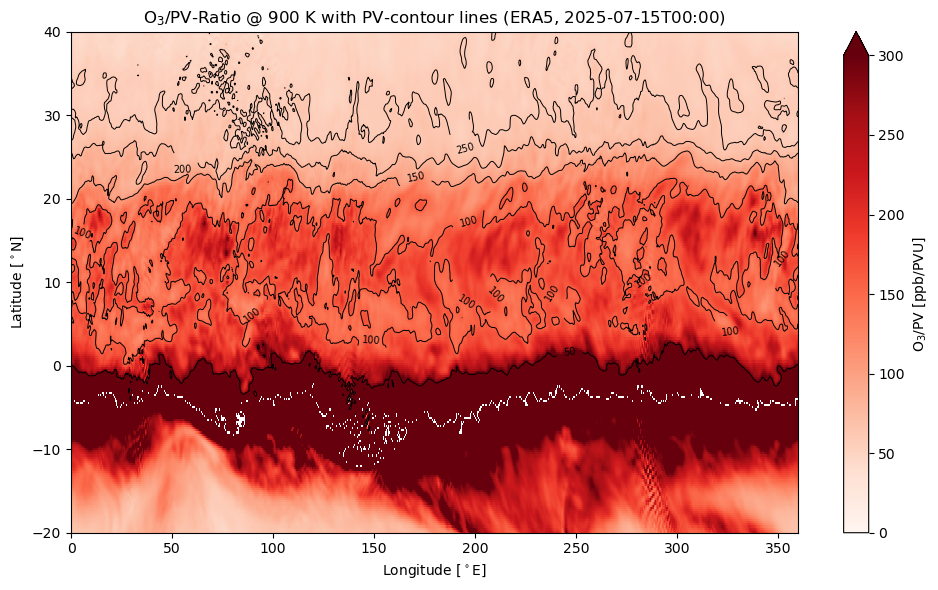

In [198]:
theta_level = 900
time_idx = 0

ratio_map = t1['o3_pv_ratio'].sel(theta=theta_level).isel(valid_time=time_idx)
pv_map = t1['pv_pvu'].sel(theta=theta_level).isel(valid_time=time_idx)

ratio_map = ratio_map.where(np.abs(pv_map) > 1)
vmax = float(np.nanpercentile(np.abs(ratio_map.values), 95))

fig, ax = plt.subplots(figsize=(10, 6))
ratio_map.plot(x='longitude', y='latitude', ax=ax, cmap='Reds', vmin=0, vmax=300,
               cbar_kwargs={'label': f"O$_3$/PV [{ratio_map.attrs.get('units', '')}]"})

cs = ax.contour(pv_map['longitude'], pv_map['latitude'], pv_map.values,
                levels=[50, 100, 150, 200, 250],
                colors='k', linewidths=0.7)
ax.clabel(cs, fmt='%.0f', fontsize=7)

ax.set_xlabel('Longitude [$^\circ$E]')
ax.set_ylim(-20, 40)
ax.set_ylabel('Latitude [$^\circ$N]')
ax.set_title(f'O$_3$/PV-Ratio @ {theta_level} K with PV-contour lines '
             f'(ERA5, {str(t1["valid_time"].isel(valid_time=time_idx).values)[:16]})')
fig.tight_layout()

<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_88181/459551444.py:19: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Longitude [$^\circ$E]')
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_88181/459551444.py:21: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude [$^\circ$N]')


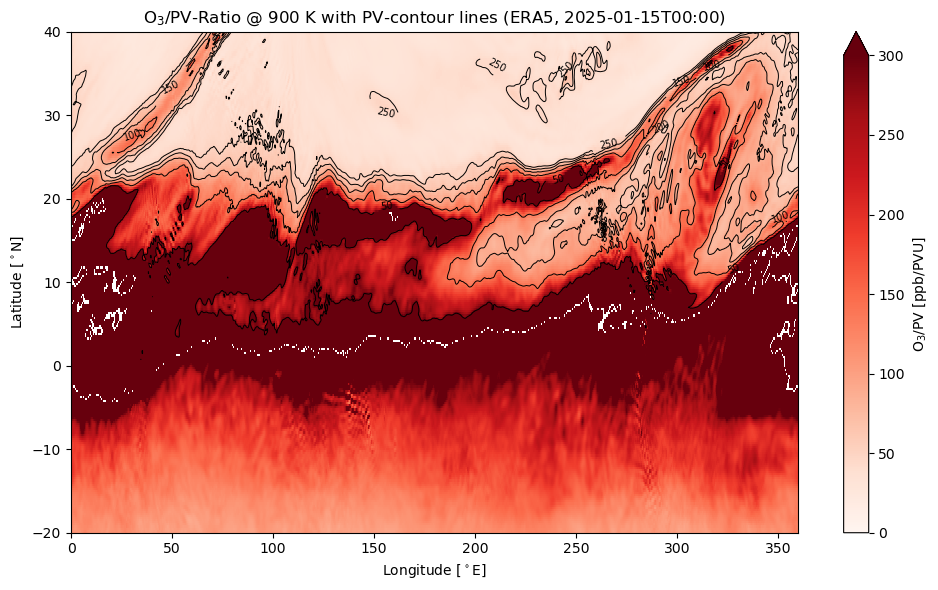

In [199]:
theta_level = 900
time_idx = 0

ratio_map = t2['o3_pv_ratio'].sel(theta=theta_level).isel(valid_time=time_idx)
pv_map = t2['pv_pvu'].sel(theta=theta_level).isel(valid_time=time_idx)

ratio_map = ratio_map.where(np.abs(pv_map) > 1)
vmax = float(np.nanpercentile(np.abs(ratio_map.values), 95))

fig, ax = plt.subplots(figsize=(10, 6))
ratio_map.plot(x='longitude', y='latitude', ax=ax, cmap='Reds', vmin=0, vmax=300,
               cbar_kwargs={'label': f"O$_3$/PV [{ratio_map.attrs.get('units', '')}]"})

cs = ax.contour(pv_map['longitude'], pv_map['latitude'], pv_map.values,
                levels=[50, 100, 150, 200, 250],
                colors='k', linewidths=0.7)
ax.clabel(cs, fmt='%.0f', fontsize=7)

ax.set_xlabel('Longitude [$^\circ$E]')
ax.set_ylim(-20, 40)
ax.set_ylabel('Latitude [$^\circ$N]')
ax.set_title(f'O$_3$/PV-Ratio @ {theta_level} K with PV-contour lines '
             f'(ERA5, {str(t2["valid_time"].isel(valid_time=time_idx).values)[:16]})')
fig.tight_layout()

In [23]:
t2

<xarray.Dataset> Size: 16GB
Dimensions:        (valid_time: 24, theta: 27, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 192B 2025-01-15 ... 2025-01-15...
  * theta          (theta) float64 216B 300.0 310.0 320.0 ... 1.3e+03 1.4e+03
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
Data variables:
    eqlat          (valid_time, theta, latitude, longitude) float32 3GB ...
    pv_isentropic  (valid_time, theta, latitude, longitude) float32 3GB 4.086...
    o3_isentropic  (valid_time, theta, latitude, longitude) float32 3GB 2.11e...
    pv_pvu         (valid_time, theta, latitude, longitude) float32 3GB 4.086...
    o3_ppb         (valid_time, theta, latitude, longitude) float32 3GB 211.0...
    o3_pv_ratio    (valid_time, theta, latitude, longitude) float32 3GB 51.65...

### PV-O3-Scatterplot auf einer Isentrope

`plot_pv_o3_scatter()` plottet `o3_ppb` gegen `pv_pvu` fuer alle Gitterpunkte einer einzelnen Isentrope (naechstgelegenes `theta`-Level), standardmaessig fuer einen einzelnen Zeitschritt. Optional werden die Punkte nach einer dritten Groesse (z.B. `eqlat` oder `latitude`) eingefaerbt, um zu sehen, ob die PV-O3-Beziehung mit der Breite variiert (z.B. straffere Kopplung innerhalb des Polarwirbels).

In [195]:
def plot_pv_o3_scatter(ds, theta_level=900, time_idx=0, lat_range=None, color_by='eqlat',
                        s=4, alpha=1, ax=None, title=None):
    """Scatter plot of O3 vs. PV on a single isentropic surface.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing pv_pvu and o3_ppb (see unit-conversion cell above)
        and, if color_by is set, that field too.
    theta_level : float
        Isentropic level [K]; the nearest available theta is used.
    time_idx : int or None
        Single time step to use (index into valid_time). None uses all time
        steps together (more points, but no single synoptic snapshot).
    lat_range : tuple of (float, float) or None
        (lat_min, lat_max) in degrees_north restricting the geographic
        latitude range (e.g. (0, 40) for 0-40 N). None uses all latitudes.
    color_by : str or None
        Name of a field to color points by (e.g. 'eqlat' or 'latitude').
        None disables coloring.
    s, alpha : float
        Scatter marker size / transparency.
    ax : matplotlib.axes.Axes or None
        Axes to draw into; a new figure is created if None.
    title : str or None
        Plot title; auto-generated from the actual theta level if None.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    da = ds.sel(theta=theta_level, method='nearest')
    if time_idx is not None:
        da = da.isel(valid_time=time_idx)
    if lat_range is not None:
        lat_min, lat_max = lat_range
        da = da.sel(latitude=slice(lat_max, lat_min))

    pv, o3 = da['pv_pvu'], da['o3_pv_ratio']
    if color_by is not None:
        pv, o3, c = xr.broadcast(pv, o3, da[color_by])
        c = c.values.ravel()
    else:
        pv, o3 = xr.broadcast(pv, o3)
        c = None

    pv, o3 = pv.values.ravel(), o3.values.ravel()
    valid = np.isfinite(pv) & np.isfinite(o3)
    if c is not None:
        valid &= np.isfinite(c)
        c = c[valid]
    pv, o3 = pv[valid], o3[valid]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    else:
        fig = ax.figure

    if c is not None:
        sc = ax.scatter(pv, o3, 
                        c=c, 
                        cmap='managua', 
                        s=s, 
                        alpha=alpha
                        )
        fig.colorbar(sc, ax=ax, label=color_by)
    else:
        ax.scatter(pv, o3, s=s, alpha=alpha, color='tab:blue')

    theta_actual = float(da['theta'])
    title_suffix = f', {lat_range[0]}-{lat_range[1]}$^\circ$N' if lat_range is not None else ''
    ax.set_xlabel('PV [PVU]')
    ax.set_ylabel('O$_3/PV$ [ppb/PVU]')
    ax.set_ylim(0,1000)
    ax.set_xlim(0,500)
    ax.set_title(title or f'O$_3/PV$ vs. PV @ {theta_actual:.0f} K{title_suffix}')
    return fig, ax

<>:71: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\c'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_88181/399223635.py:71: SyntaxWarning: invalid escape sequence '\c'
  title_suffix = f', {lat_range[0]}-{lat_range[1]}$^\circ$N' if lat_range is not None else ''


(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'O$_3$ vs. PV @ 900 K, 0-90$^\\circ$N'}, xlabel='PV [PVU]', ylabel='O$_3/PV$ [ppb/PVU]'>)

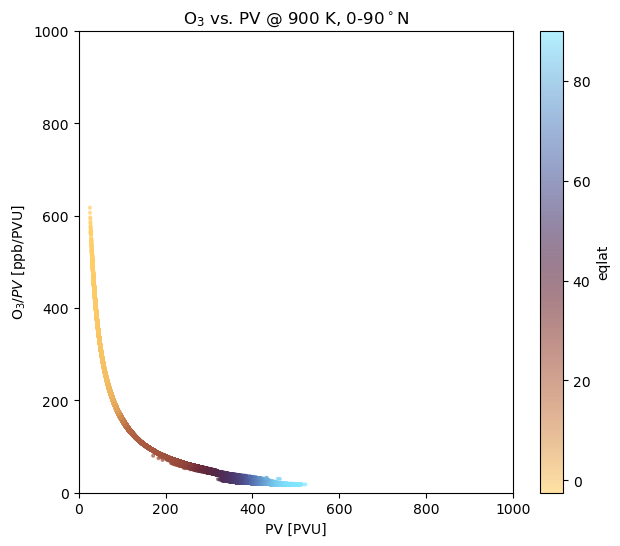

In [187]:
plot_pv_o3_scatter(t1, theta_level=900, time_idx=0, lat_range=(0, 90))

(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'O$_3/PV$ vs. PV @ 900 K, 0-90$^\\circ$N'}, xlabel='PV [PVU]', ylabel='O$_3/PV$ [ppb/PVU]'>)

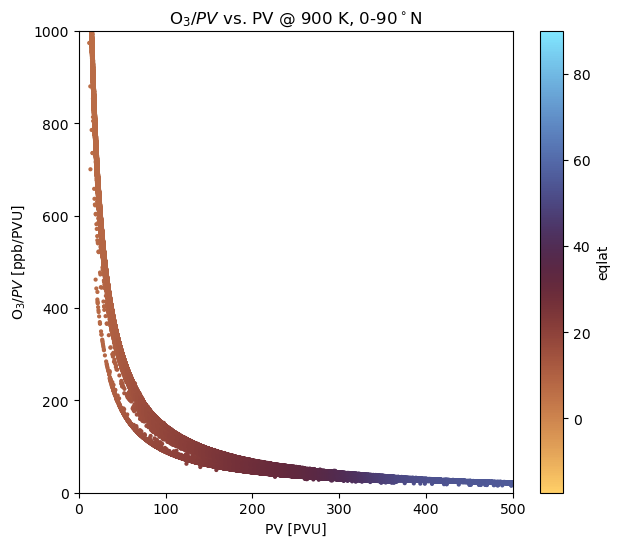

In [196]:
plot_pv_o3_scatter(t2, theta_level=900, time_idx=0, lat_range=(0,90))

## Latitude vs. Theta und EqLat vs. Theta

Beide Klimatologien werden mit derselben `create_2d_climatology()`-Funktion berechnet: `o3_isentropic` wird gegen `theta_bins = np.linspace(400, 1000, 16)` und die jeweilige Koordinate (`latitude` bzw. `eqlat`) gebinnt (analog zu `create_2d_climatology` in `03_ozone_satellite_comparison.ipynb`, hier generalisiert auf das gegittete (time, theta, lat, lon)-Feld via `xr.broadcast`).

In [5]:
theta_bins = np.linspace(400, 1000, 16)
lat_bins = np.linspace(-90, 90, 37)
eqlat_bins = np.linspace(-90, 90, 37)


def create_2d_climatology(var, coord, theta_bins, coord_bins, min_count=3):
    """2D binned climatology of `var` against theta and an arbitrary coordinate.

    Generalizes `create_2d_climatology` from 03_ozone_satellite_comparison.ipynb
    to gridded (time, theta, lat, lon) fields: `coord` is broadcast against
    `var` first, so it can be a 1D coordinate (e.g. latitude) or a field with
    the same shape as var (e.g. eqlat).

    Parameters
    ----------
    var : xr.DataArray
        Variable to average, must have a 'theta' dimension (e.g. o3_isentropic).
    coord : xr.DataArray
        Coordinate to bin against (e.g. latitude or eqlat).
    theta_bins, coord_bins : array_like
        Bin edges.
    min_count : int
        Bins with <= this many valid observations are masked to NaN.

    Returns
    -------
    mean, std, count : xr.DataArray
        All with dims (theta, <coord.name>), bin centers as coordinates.
    """
    var_b, coord_b, theta_b = xr.broadcast(var, coord, var['theta'])
    flat_v = var_b.values.ravel()
    flat_c = coord_b.values.ravel()
    flat_t = theta_b.values.ravel()
    valid = np.isfinite(flat_v) & np.isfinite(flat_c) & np.isfinite(flat_t)

    bin_counts, t_e, c_e, _ = binned_statistic_2d(
        flat_t[valid], flat_c[valid], flat_v[valid], statistic='count', bins=[theta_bins, coord_bins])
    bin_means, _, _, _ = binned_statistic_2d(
        flat_t[valid], flat_c[valid], flat_v[valid], statistic='mean', bins=[theta_bins, coord_bins])
    bin_std, _, _, _ = binned_statistic_2d(
        flat_t[valid], flat_c[valid], flat_v[valid], statistic='std', bins=[theta_bins, coord_bins])

    low_count = bin_counts <= min_count
    bin_means[low_count] = np.nan
    bin_std[low_count] = np.nan

    coord_name = coord.name or 'coord'
    t_centers = 0.5 * (theta_bins[:-1] + theta_bins[1:])
    c_centers = 0.5 * (coord_bins[:-1] + coord_bins[1:])
    dims = ['theta', coord_name]
    coords = {'theta': t_centers, coord_name: c_centers}
    return (xr.DataArray(bin_means, dims=dims, coords=coords),
            xr.DataArray(bin_std, dims=dims, coords=coords),
            xr.DataArray(bin_counts, dims=dims, coords=coords))


# o3_lat_theta, o3_lat_theta_std, o3_lat_theta_counts = create_2d_climatology(
#     t['o3_isentropic'], t['latitude'], theta_bins, lat_bins)

# fig, ax = plt.subplots(figsize=(8, 5))
# o3_lat_theta.plot(x='latitude', y='theta', ax=ax, cbar_kwargs={'label': 'O$_3$ [' + t['o3_isentropic'].attrs.get('units', '') + ']'})
# ax.set_xlabel('Latitude [$^\circ$N]')
# ax.set_ylabel(r'$\Theta$ [K]')
# ax.set_title('O$_3$ Climatology: Latitude vs. Theta (20250715)')
# fig.tight_layout()

`eqlat` ist selbst ein Feld auf dem (time, theta, lat, lon)-Gitter (der Aequivalentbreitenwert des PV-Konturs durch jeden Gitterpunkt). `create_2d_climatology()` bint es genauso wie `latitude` oben, nur mit `eqlat_bins` statt `lat_bins`.

<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_87040/47421482.py:6: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Equivalent Latitude [$^\circ$N]')


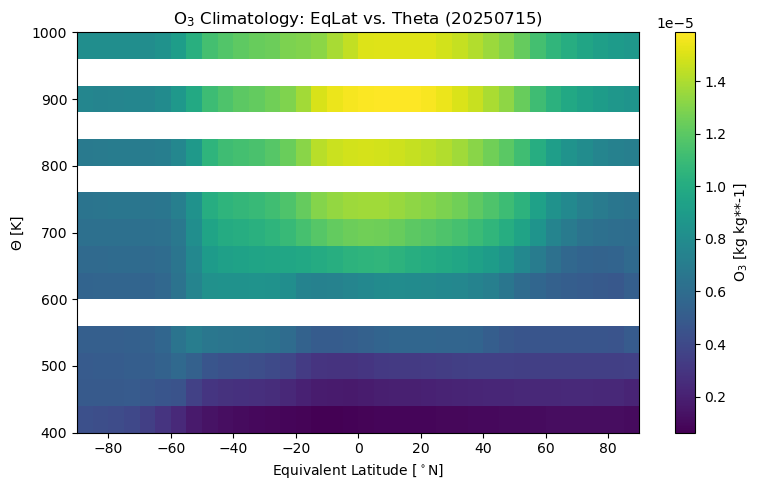

In [14]:
o3_eqlat_theta, o3_eqlat_theta_std, o3_eqlat_theta_counts = create_2d_climatology(
    t['o3_isentropic'], t['eqlat'], theta_bins, eqlat_bins)

fig, ax = plt.subplots(figsize=(8, 5))
o3_eqlat_theta.plot(x='eqlat', y='theta', ax=ax, cbar_kwargs={'label': 'O$_3$ [' + t['o3_isentropic'].attrs.get('units', '') + ']'})
ax.set_xlabel('Equivalent Latitude [$^\circ$N]')
ax.set_ylabel(r'$\Theta$ [K]')
ax.set_title('O$_3$ Climatology: EqLat vs. Theta (20250715)')
fig.tight_layout()

## Direkter Vergleich

Nebeneinander geplottet, gleiche Farbskala, um zu sehen, wie stark EqLat- vs. geographische Breite die Struktur veraendert (z.B. schaerfere Gradienten am Polarwirbelrand in EqLat).

<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_87040/1652641543.py:9: SyntaxWarning: invalid escape sequence '\c'
  axes[0].set_xlabel('Latitude [$^\circ$N]')
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_87040/1652641543.py:15: SyntaxWarning: invalid escape sequence '\c'
  axes[1].set_xlabel('Equivalent Latitude [$^\circ$N]')


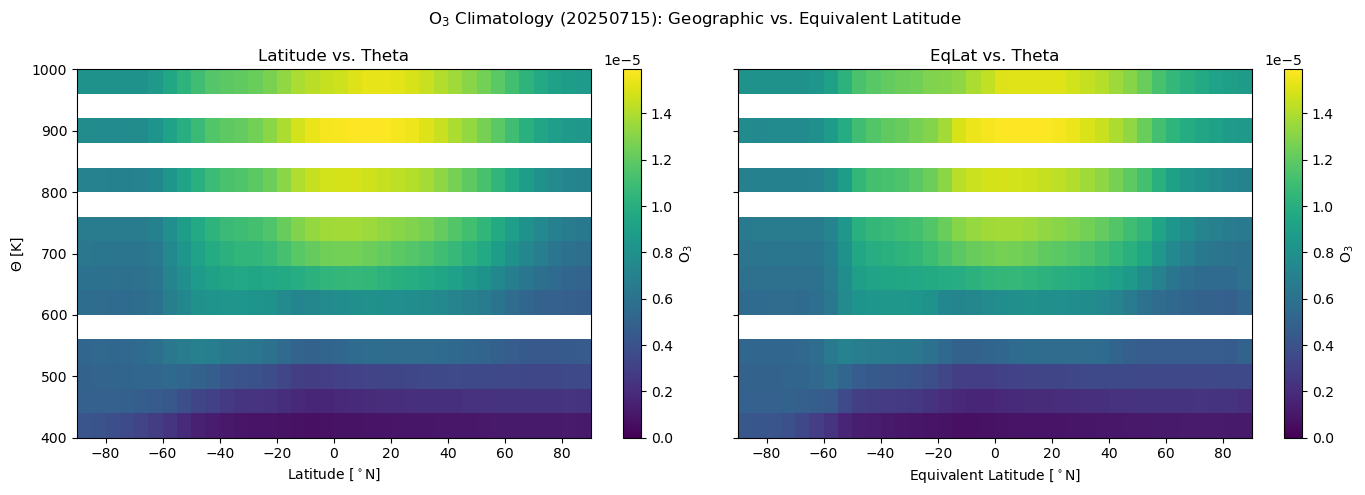

In [15]:
vmin = 0
vmax = float(max(o3_lat_theta.max(), o3_eqlat_theta.max()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

o3_lat_theta.plot(x='latitude', y='theta', ax=axes[0], vmin=vmin, vmax=vmax,
                   cbar_kwargs={'label': 'O$_3$'})
axes[0].set_title('Latitude vs. Theta')
axes[0].set_xlabel('Latitude [$^\circ$N]')
axes[0].set_ylabel(r'$\Theta$ [K]')

o3_eqlat_theta.plot(x='eqlat', y='theta', ax=axes[1], vmin=vmin, vmax=vmax,
                     cbar_kwargs={'label': 'O$_3$'})
axes[1].set_title('EqLat vs. Theta')
axes[1].set_xlabel('Equivalent Latitude [$^\circ$N]')
axes[1].set_ylabel('')

fig.suptitle('O$_3$ Climatology (20250715): Geographic vs. Equivalent Latitude')
fig.tight_layout()

## Std/RSD-Differenz: EqLat vs. geographische Breite (reine ERA5-Daten)

Analog zu `plot_std_difference()` in `03_ozone_satellite_comparison.ipynb`, hier aber direkt auf dem ERA5-Gitter (`t`) ohne MLS-Vergleich: pro Theta/Koordinaten-Bin wird die Standardabweichung (oder relative Standardabweichung) von `o3_isentropic` bei EqLat-Binning mit der bei geographischer-Breiten-Binning verglichen. Ein negativer Wert (blau) heisst, EqLat erzeugt eine geringere Streuung innerhalb der Bins, ist also die kohaerentere Koordinate fuer Ozon an dieser Stelle (z.B. am Polarwirbelrand).

In [6]:
def plot_std_difference(ds, var_name='o3_isentropic',
                        geo_coord='latitude',
                        eqlat_coords=('eqlat',),
                        plot_type='std',
                        diff_lims=(None, None),
                        theta_bins=theta_bins,
                        coord_bins=lat_bins,
                        title="Std-Differenz: EqLat − Geographische Breite (ERA5)"):
    """
    Plots the difference in standard deviation (or relative std dev) between
    equivalent latitude and geographic latitude binning, for a single gridded
    ERA5 eqlat/isentropic Dataset (no MLS/MERRA2 comparison).

    Adapted from `plot_std_difference` in 03_ozone_satellite_comparison.ipynb:
    same idea, but `ds` is the raw (time, theta, lat, lon) ERA5 Dataset and
    binning goes through this notebook's `create_2d_climatology`, which
    broadcasts `geo_coord`/`eqlat_coords` against `var_name` instead of
    assuming they are already flattened per-observation columns.

    A negative difference indicates that EqLat binning produces less within-bin
    variability, meaning EqLat is a more coherent coordinate for that tracer.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing var_name, geo_coord and eqlat_coords (e.g. `t`).
    var_name : str, optional
        Name of the variable to analyse. Default: 'o3_isentropic'.
    geo_coord : str, optional
        Name of the geographic latitude coordinate. Default: 'latitude'.
    eqlat_coords : sequence of str, optional
        Equivalent latitude field name(s) to compare against geo_coord.
        Default: ('eqlat',).
    plot_type : {'std', 'rsd'}, optional
        'std' - difference of absolute standard deviations.
        'rsd' - difference of relative standard deviations (std / mean,
                i.e. coefficient of variation). Default: 'std'.
    diff_lims : tuple of (float or None, float or None), optional
        (vmin, vmax) for the colour scale. If None, limits are derived
        symmetrically from the data. Default: (None, None).
    theta_bins : array_like, optional
        Bin edges for the potential temperature axis.
    coord_bins : array_like, optional
        Bin edges for the latitude / equivalent latitude axis.
    title : str, optional
        Figure super-title.
    """
    # Reference statistics on geographic latitude
    m_geo, s_geo, _ = create_2d_climatology(
        ds[var_name], ds[geo_coord], theta_bins, coord_bins)

    if plot_type == 'rsd':
        ref_data = s_geo / m_geo.where(m_geo != 0)
        unit_label = 'ΔRSD [fraction]'
    else:
        ref_data = s_geo
        unit_label = f"ΔStd Dev [{ds[var_name].attrs.get('units', '')}]"

    n_rows = len(eqlat_coords)
    fig, axes = plt.subplots(n_rows, 1, figsize=(9, 4.5 * n_rows),
                             sharex=True, sharey=True, constrained_layout=True,
                             squeeze=False)
    axes = axes[:, 0]
    fig.suptitle(title, fontsize=16, fontweight='bold')

    for ax, eqlat_coord in zip(axes, eqlat_coords):
        m_eq, s_eq, _ = create_2d_climatology(
            ds[var_name], ds[eqlat_coord], theta_bins, coord_bins)

        if plot_type == 'rsd':
            eq_data = s_eq / m_eq.where(m_eq != 0)
        else:
            eq_data = s_eq

        # Same coord_bins for both, but the bin dimension is named after
        # geo_coord/eqlat_coord respectively - rename to a shared axis so
        # xarray aligns by bin center instead of broadcasting.
        diff = (eq_data.rename({eqlat_coord: 'coord'}).values
                - ref_data.rename({geo_coord: 'coord'}).values)
        diff = xr.DataArray(diff, dims=['theta', 'coord'],
                            coords={'theta': ref_data['theta'].values,
                                    'coord': ref_data[geo_coord].values})

        vmax = diff_lims[1] if diff_lims[1] is not None else float(np.nanmax(np.abs(diff)))
        vmin = diff_lims[0] if diff_lims[0] is not None else -vmax

        diff.plot(x='coord', y='theta', ax=ax, cmap='RdBu_r', vmin=vmin, vmax=vmax,
                 cbar_kwargs={'label': unit_label})
        ax.set_title(f'{eqlat_coord} − {geo_coord}  ({plot_type.upper()})', fontsize=13)
        ax.set_ylabel(r'$\Theta$ [K]', fontsize=14)

    axes[-1].set_xlabel('Latitude / Equivalent Latitude [$^\circ$N]', fontsize=14)
    return fig, axes

<>:92: SyntaxWarning: invalid escape sequence '\c'
<>:92: SyntaxWarning: invalid escape sequence '\c'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_88302/2153235718.py:92: SyntaxWarning: invalid escape sequence '\c'
  axes[-1].set_xlabel('Latitude / Equivalent Latitude [$^\circ$N]', fontsize=14)


(<Figure size 900x450 with 2 Axes>,
 array([<Axes: title={'center': 'eqlat − latitude  (RSD)'}, xlabel='Latitude / Equivalent Latitude [$^\\circ$N]', ylabel='$\\Theta$ [K]'>],
       dtype=object))

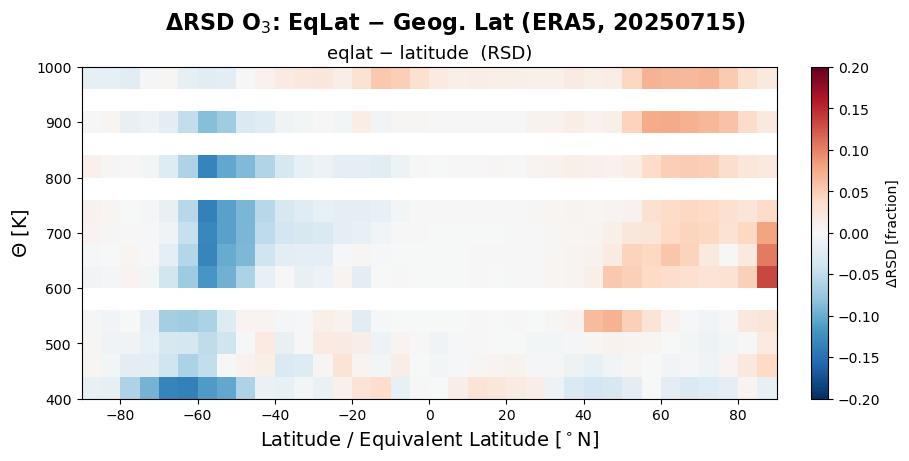

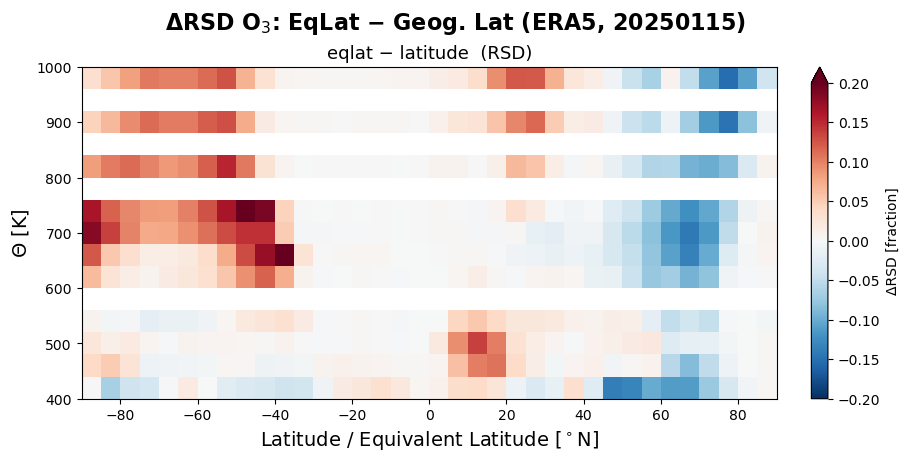

In [7]:
# plot_type='std' -> absolute Differenz der Standardabweichung
# plot_type='rsd' -> Differenz der relativen Standardabweichung (Variationskoeffizient)
plot_std_difference(t1, 'o3_isentropic',
                    geo_coord='latitude',
                    eqlat_coords=['eqlat'],
                    plot_type='rsd',
                    diff_lims=(-0.2, 0.2),
                    title="ΔRSD O$_3$: EqLat − Geog. Lat (ERA5, 20250715)")

plot_std_difference(t2, 'o3_isentropic',
                    geo_coord='latitude',
                    eqlat_coords=['eqlat'],
                    plot_type='rsd',
                    diff_lims=(-0.2, 0.2),
                    title="ΔRSD O$_3$: EqLat − Geog. Lat (ERA5, 20250115)")

In [1]:
t1

NameError: name 't1' is not defined

In [ ]:
t